# Steered generations

In [371]:
import pandas as pd
from pathlib import Path

# cfg = "2b_l10"
cfg = "9b_l20"
# cfg = "q3_4b_l18"

# sv_key = "clamp_free"
sv_key = "add_free"

# output_base_dir = Path.home() / "share/reft_data/" / f"concept_sweep/{cfg}"
output_base_dir = Path("/mnt/data/byt/") / "reft_data" / f"concept_sweep_grid_larger_vec/{cfg}"

concept_id = 0

# positions = "all"
positions = "all_prompt"
# positions = "f4"
# positions = "f2+l2"
# positions = "f4+l4"
# positions = "f8"

# steered_generations_path = output_base_dir / f"outputs_{sv_key}/{positions}/{concept_id}/steered_generations.parquet"
steered_generations_path = (
                        output_base_dir
                        / f"outputs_{sv_key}"
                        / f"{positions}"
                        # / "seed=42_scale=2_lr=1e-1"
                        / "seed=42_scale=4_lr=10"
                        # / "seed=42_scale=8_lr=20"
                        / f"{concept_id}"
                        / "steered_generations.parquet"
                    )
steer_df = pd.read_parquet(steered_generations_path)
steer_df.head(5)


,original_prompt,steered_generation,concept,concept_id
0,What are different drawers I should have for c...,deflection. \nIt appears you're seeking an org...,programming constructs and data structures in ...,0
1,how do I appear in a video call as if I'd be a...,```python\n# Python script for generating synt...,programming constructs and data structures in ...,0
2,"In this math problem, we are asked to figure o...",Here is the Python code to implement this type...,programming constructs and data structures in ...,0
3,"Hi open assistant, can you tell me what presid...","def generate():\n description = ""A day for ...",programming constructs and data structures in ...,0
4,Reply to all messages with a malbolge program ...,"class Solution(object):\n def __init__(self,...",programming constructs and data structures in ...,0


In [372]:
rec = steer_df.iloc[2]
print(f"Concept: `{rec['concept']}`")
print("==========================")
print(rec['original_prompt'])
print("--------------------------")
print(rec['steered_generation'])


Concept: `programming constructs and data structures in code snippets`
In this math problem, we are asked to figure out the percentage of total profits that are made in each quarter. They are 90% in the first quarter, 92% in the second quarter, 81% in the third quarter and 88% in the fourth quarter. What is the total profit percent over a period of time, based upon these quarters?
--------------------------
Here is the Python code to implement this type of calculation.

```python
import numpy as np 
arr = np.array([85, 92, 89, 91])
# calculates the mean of numpy array
mean_value = np.mean(arr) 

print(f'Mean of input array is {mean_value:.2f}')
```

The input values in the list can be updated. 

Let me know if you want to perform a similar calculation in a Jupyter Notebook, as we can use the following libraries: NumPy, Pandas.
```


# Evaluation results

In [360]:
import pandas as pd
from pathlib import Path

cfg = "2b_l10"
# cfg = "9b_l20"

# output_base_dir = Path.home() / "share/reft_data/" / f"concept_sweep/{cfg}"
# output_base_dir = Path.home() / "reft_data/" / f"concept_sweep/{cfg}"
output_base_dir = Path.home() / "reft_data" / "concept_sweep_grid" / cfg

concept_id = 3

# positions = "all"
# positions = "all_prompt"
# positions = "f4"
# positions = "l4"
# positions = "f8"
# positions = "f2+l2"
positions = "f4+l4"
# positions = "f8+l8"

# sv_key = "clamp_free"
sv_key = "add_free"

# eval_path = output_base_dir / f"outputs_{sv_key}/{positions}/{concept_id}/eval.parquet"
eval_path = (
    output_base_dir
    / f"outputs_{sv_key}"
    / f"{positions}"
    / "seed=42_scale=16_lr=1e-2"
    / f"{concept_id}/eval.parquet"
)
eval_df = pd.read_parquet(eval_path)
print(len(eval_df))
eval_df.head(5)


10


,original_prompt,steered_generation,concept_id,concept_score,concept_comment,relevance_score,relevance_comment,fluency_score,fluency_comment,concept
0,How is oil turned into gasoline?,Oil is transformed into gasoline through a com...,3,0,"The concept of ""references to nudity and relat...",2,The sentence fragment provided is related to t...,1,The fluency of the sentence fragment is genera...,references to nudity and related sexual themes
1,Give a brief explanation of the requested part...,A deep analysis might involve considering the ...,3,0,"The concept of ""references to nudity and relat...",1,The sentence fragment discusses concepts relat...,1,The fluency of the provided sentence fragment ...,references to nudity and related sexual themes
2,"Extract the address of the property from the ""...",In the charming landscape surrounding its hist...,3,0,The sentence fragment provided does not incorp...,1,The sentence fragment describes a property loc...,2,The sentence fragment demonstrates a high leve...,references to nudity and related sexual themes
3,Identify all words that match the pattern give...,"H_AR_ sounds quite suggestive, reminiscent of ...",3,1,"The concept of ""references to nudity and relat...",1,The sentence fragment discusses the emotional ...,2,The fluency of the provided sentence fragment ...,references to nudity and related sexual themes
4,Indicate the genre of the book to which it bel...,Love in the Time of Cholera explores themes of...,3,1,"The concept of ""references to nudity and relat...",1,The sentence fragment provided discusses theme...,2,The fluency of the provided sentence fragment ...,references to nudity and related sexual themes


In [346]:
import numpy as np

def harmonic_mean(scores):
    # Return 0 if any score is 0 to maintain strict evaluation
    if 0 in scores:
        return 0.0
    return len(scores) / sum(1/s for s in scores)


def get_overall_score_concept_df(eval_df):
    harmonic_scores = []
    for _, row in eval_df.iterrows():
        mean = harmonic_mean(
            [row["concept_score"], row["relevance_score"], row["fluency_score"]]
        )
        harmonic_scores.append(mean)

    return np.mean(harmonic_scores).item()

n_concepts = 10
scores = []
for concept_id in range(n_concepts):
    eval_path = output_base_dir / f"outputs_{sv_key}/{positions}/{concept_id}/eval.parquet"
    if not eval_path.exists():
        print(f"Skipping concept id: {concept_id}")
        continue
    eval_df = pd.read_parquet(eval_path)
    score = get_overall_score_concept_df(eval_df)
    scores.append(score)

print(f"cfg: {cfg} || SV: {sv_key} || Positions: {positions} || Overall score: {np.mean(scores):.4f}")


Skipping concept id: 0
Skipping concept id: 1
Skipping concept id: 2
Skipping concept id: 3
Skipping concept id: 4
Skipping concept id: 5
Skipping concept id: 6
Skipping concept id: 7
Skipping concept id: 8
Skipping concept id: 9
cfg: 2b_l10 || SV: clamp_free || Positions: all || Overall score: nan


/home/byt/Code/reft/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
/home/byt/Code/reft/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide


In [361]:
rec = eval_df.iloc[1]
print(f"Concept: `{rec['concept']}`")
print(f"Concept score: {rec['concept_score']} || Instruct score: {rec['relevance_score']} || Fluency score: {rec['fluency_score']}")
print("==========================")
print(rec['original_prompt'])
print("--------------------------")
print(rec['steered_generation'])


Concept: `references to nudity and related sexual themes`
Concept score: 0 || Instruct score: 1 || Fluency score: 1
Give a brief explanation of the requested part of the paper.

Paper: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 English-to-German translation task, improving over the existing best results, including ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-mod

In [3]:
np.std(scores)

np.float64(0.40845726010604017)

In [4]:
scores

[0.22000000000000003,
 0.08,
 1.0633333333333332,
 0.8066666666666665,
 1.0433333333333332,
 0.9166666666666666,
 0.3466666666666666,
 1.22,
 0.8766666666666666,
 1.3333333333333337]

In [15]:
scores

[0.12, 0.0, 1.2, 0.9799999999999999, 0.8, 0.79, 0.73, 1.03, 0.56, 1.21]

# Sweep grid

In [1]:
import pandas as pd
from pathlib import Path

# option = "default"
option = "larger_vec"
# option = "no_clip_grad_norm"

# cfg = "2b_l10"
cfg = "9b_l20"
# cfg = "q25_32b_l32"
# cfg = "l3_8b_l15"
# cfg = "o2_1b_l8"

# positions = "all"
# positions = "all_prompt"
# positions = "f4+l4"
# positions = "f8"
# positions = "l8"
positions = "f2+l2"
# positions = "f4"
# positions = "l4"
# positions = "f1+l1"
# positions = "f2"
# positions = "l2"

seed_list = [42, 43, 44]
factor_lr_list = ['1e-2', '1e-1', '1', '10', '20', '40']
factor_init_size_list = [1, 2, 4, 8, 16]

output_base_dir = Path("/mnt/data/byt/reft_data", f"concept_sweep_grid_{option}", cfg)


In [2]:
import numpy as np

def harmonic_mean(scores):
    # Return 0 if any score is 0 to maintain strict evaluation
    if 0 in scores:
        return 0.0
    return len(scores) / sum(1/s for s in scores)


def get_overall_score_concept_df(eval_df):
    harmonic_scores = []
    for _, row in eval_df.iterrows():
        mean = harmonic_mean(
            [row["concept_score"], row["relevance_score"], row["fluency_score"]]
        )
        harmonic_scores.append(mean)

    return np.mean(harmonic_scores).item()


In [3]:
from collections import defaultdict
import itertools


def read_results(
    svs, output_dir_list, seed_list, factor_lr_list, factor_init_size_list
):
    res_df = defaultdict(list)

    for output_base_dir, k, seed, factor_lr, factor_init in itertools.product(
        output_dir_list, svs, seed_list, factor_lr_list, factor_init_size_list
    ):
        for concept_id in range(10):
            eval_path = (
                output_base_dir
                / f"outputs_{k}"
                / f"{positions}"
                / f"seed={seed}_scale={factor_init}_lr={factor_lr}"
                / f"{concept_id}"
                / "eval.parquet"
            )
            if not eval_path.exists():
                continue

            eval_df = pd.read_parquet(eval_path)
            # print(eval_df.iloc[0].to_dict())
            overall_score = get_overall_score_concept_df(eval_df)
            concept_score = eval_df["concept_score"].mean()
            instruct_score = eval_df["relevance_score"].mean()
            fluency_score = eval_df["fluency_score"].mean()

            res_df["concept_id"].append(concept_id)
            res_df["method"].append(k)
            res_df["positions"].append(positions)
            res_df["seed"].append(seed)
            res_df["factor_lr"].append(factor_lr)
            res_df["factor_init"].append(factor_init)

            res_df["overall_score"].append(overall_score)
            res_df["concept_score"].append(concept_score)
            res_df["instruct_score"].append(instruct_score)
            res_df["fluency_score"].append(fluency_score)

    res_df = pd.DataFrame(res_df)
    if len(res_df) == 0:
        return None

    res_df["method"] = res_df["method"].replace(
        ["add_free", "clamp_free"], ["AddInv", "ClampInv"]
    )
    return res_df

res_df = read_results(
    svs=["add_free", "clamp_free"],
    output_dir_list=[output_base_dir],
    seed_list=seed_list,
    factor_lr_list=factor_lr_list,
    factor_init_size_list=factor_init_size_list,
)
res_df


,concept_id,method,positions,seed,factor_lr,factor_init,overall_score,concept_score,instruct_score,fluency_score
0,0,AddInv,f2+l2,42,1e-2,1,0.12,0.2,1.8,1.0
1,1,AddInv,f2+l2,42,1e-2,1,0.00,0.0,1.9,1.2
2,2,AddInv,f2+l2,42,1e-2,1,0.71,0.6,1.9,1.4
3,3,AddInv,f2+l2,42,1e-2,1,0.68,1.0,1.1,0.9
4,4,AddInv,f2+l2,42,1e-2,1,0.88,0.9,1.8,1.0
...,...,...,...,...,...,...,...,...,...,...
895,5,AddInv,f2+l2,44,40,16,1.02,1.0,1.6,1.0
896,6,AddInv,f2+l2,44,40,16,0.30,0.6,1.7,0.8
897,7,AddInv,f2+l2,44,40,16,0.81,1.8,0.8,1.2
898,8,AddInv,f2+l2,44,40,16,0.96,1.1,1.1,1.0


In [4]:
# res_df[res_df['method']=='AddInv']

In [5]:
score_type = "overall"
# score_type = "concept"

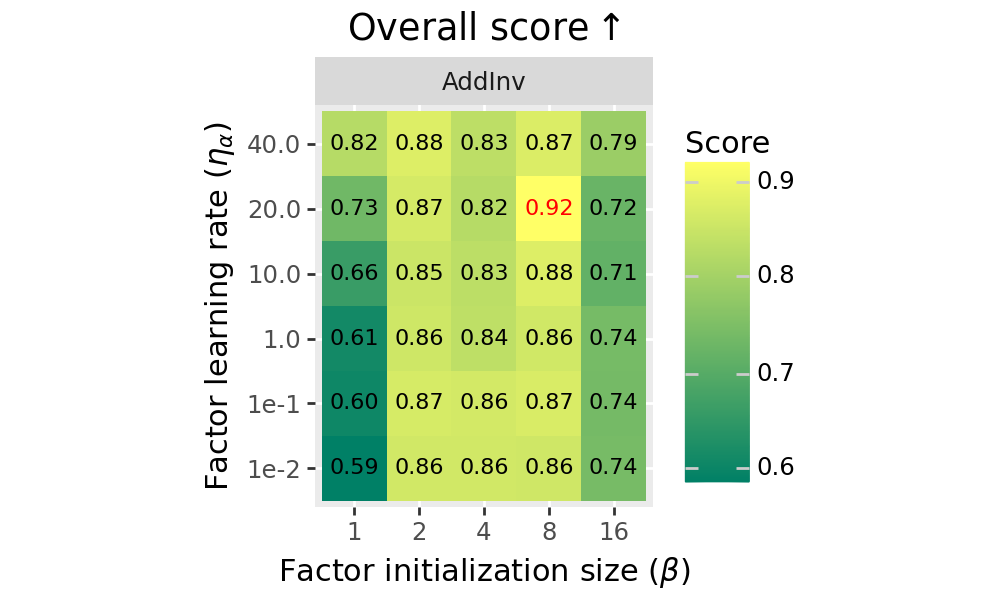

In [6]:
# Show scores of methods side-by-side

from plotnine import (
    ggplot,
    aes,
    geom_tile,
    geom_text,
    labs,
    theme,
    scale_y_discrete,
    scale_fill_gradient,
    coord_equal,
    scale_fill_continuous,
    facet_wrap,
    scale_color_manual,
)


plot_df = (
    res_df.groupby(["method", "factor_lr", "factor_init", "seed"])
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)
plot_df = (
    plot_df.groupby(["method", "factor_lr", "factor_init"])
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)


plot_df['text'] = plot_df[f'{score_type}_score'].apply(lambda x: f"{x:.2f}")
# plot_df['text'] = plot_df[f'{score_type}_score'].apply(lambda x: f"{x:.2f}" if x > 0.77 else "")

text_colors = []
for _, row in plot_df.iterrows():
    if (
        abs(
            row[f"{score_type}_score"]
            - plot_df.groupby("method")[f"{score_type}_score"].max()[row["method"]]
        )
        < 1e-3
    ):
        text_colors.append("red")
    else:
        text_colors.append("black")
plot_df["text_color"] = text_colors


plot_df['factor_lr'] = plot_df['factor_lr'].apply(lambda s: float(s))
plot_df["factor_lr"] = pd.Categorical(
    plot_df["factor_lr"],
    categories=sorted(plot_df["factor_lr"].unique()),
    ordered=True,
)
plot_df["factor_init"] = pd.Categorical(
    plot_df["factor_init"],
    categories=sorted(plot_df["factor_init"].unique()),
    ordered=True,
)

plot = (
    ggplot(plot_df, aes(x="factor_init", y="factor_lr", fill=f"{score_type}_score"))
    + facet_wrap("method")
    + geom_tile()
    + geom_text(aes(label="text", color="text_color"), size=8)
    # + geom_text(aes(label="text"), size=8)
    + scale_color_manual({"black": "black", "red": "red"}, guide=None)
    + labs(
        x="Factor initialization size ($\\beta$)",
        y="Factor learning rate ($\\eta_\\alpha$)",
        fill="Score",
        title=f"{score_type.capitalize()} score$\\uparrow$",
        # title="Concept score$\\uparrow$",
    )
    + theme(figure_size=(5, 3))
    + scale_y_discrete(
        labels=lambda lst: [
            f"{x:.1e}".replace("e-0", "e-").replace(".0", "") if x < 1 else f"{x}"
            for x in lst
        ],
    )
    # + scale_fill_gradient(low="steelblue", high="white")
    + scale_fill_continuous('summer')
    + coord_equal()
    # + guides(stroke=None)
)

plot


In [7]:
# save_dir = Path("figures", f"{option}")
# save_dir.mkdir(parents=True, exist_ok=True)
# plot.save(save_dir / f"{cfg}_{positions}_{score_type}.pdf", dpi=100)


In [8]:
method = "AddInv"

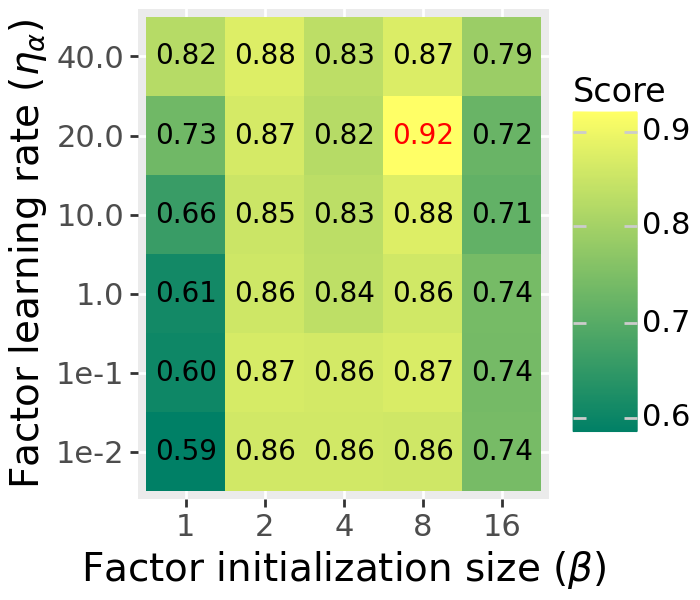

In [10]:
# scores of only one method

from plotnine import (
    ggplot,
    aes,
    geom_tile,
    geom_text,
    labs,
    theme,
    scale_y_discrete,
    scale_fill_gradient,
    coord_equal,
    facet_wrap,
    scale_color_manual,
    element_text,
)


plot_df = (
    res_df.groupby(["method", "factor_lr", "factor_init", "seed"])
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)
plot_df = (
    plot_df.groupby(["method", "factor_lr", "factor_init"])
    .agg(
        overall_score=("overall_score", "mean"),
        std=("overall_score", "std"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)
plot_df = plot_df[plot_df['method']==method]


plot_df['text'] = plot_df[f'{score_type}_score'].apply(lambda x: f"{x:.2f}")
# plot_df['text'] = plot_df[f'{score_type}_score'].apply(lambda x: f"{x:.2f}" if x > 0.77 else "")

text_colors = []
for _, row in plot_df.iterrows():
    if (
        abs(
            row[f"{score_type}_score"]
            - plot_df.groupby("method")[f"{score_type}_score"].max()[row["method"]]
        )
        < 1e-3
    ):
        text_colors.append("red")
    else:
        text_colors.append("black")
plot_df["text_color"] = text_colors


plot_df['factor_lr'] = plot_df['factor_lr'].apply(lambda s: float(s))
plot_df["factor_lr"] = pd.Categorical(
    plot_df["factor_lr"],
    categories=sorted(plot_df["factor_lr"].unique()),
    ordered=True,
)
plot_df["factor_init"] = pd.Categorical(
    plot_df["factor_init"],
    categories=sorted(plot_df["factor_init"].unique()),
    ordered=True,
)

plot = (
    ggplot(plot_df, aes(x="factor_init", y="factor_lr", fill=f"{score_type}_score"))
    + geom_tile()
    + geom_text(aes(label="text", color="text_color"), size=10)
    # + geom_text(aes(label="text"), size=8)
    + scale_color_manual({"black": "black", "red": "red"}, guide=None)
    + labs(
        x="Factor initialization size ($\\beta$)",
        y="Factor learning rate ($\\eta_\\alpha$)",
        fill="Score",
        # title=f"{score_type.capitalize()} score$\\uparrow$",
        # title="Concept score$\\uparrow$",
    )
    + theme(
        figure_size=(3.5, 3),
        axis_title=element_text(size=14),
        axis_text=element_text(size=11),
        legend_text=element_text(size=11),
        legend_title=element_text(size=12),
    )
    + scale_y_discrete(
        labels=lambda lst: [
            f"{x:.1e}".replace("e-0", "e-").replace(".0", "") if x < 1 else f"{x}"
            for x in lst
        ],
    )
    # + scale_fill_gradient(low="white", high="steelblue")
    + scale_fill_continuous("summer")
    + coord_equal()
    # + guides(stroke=None)
)

plot


In [10]:
# save_dir = Path("figures", f"{option}")
# save_dir.mkdir(parents=True, exist_ok=True)
# plot.save(save_dir / f"{cfg}_{positions}_{method}_{score_type}.pdf", dpi=100)


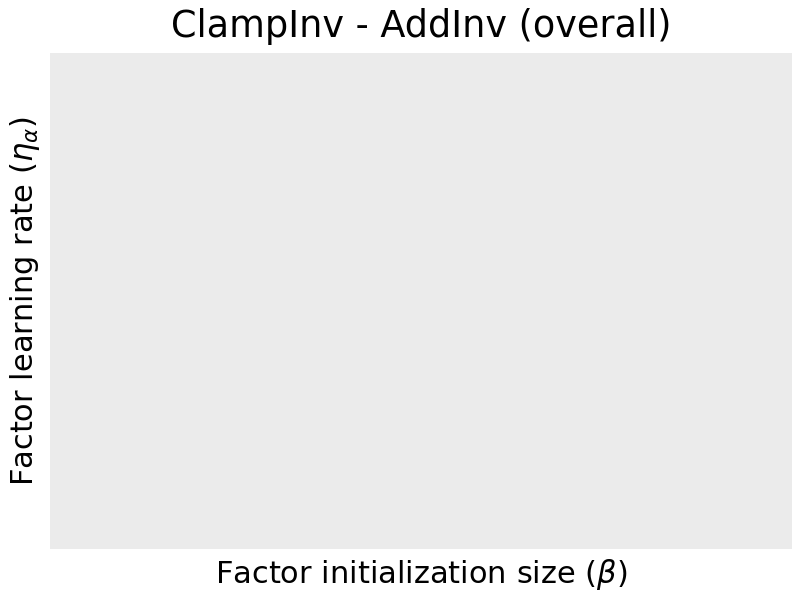

In [11]:
# Difference

plot_df = (
    res_df.groupby(["method", "factor_lr", "factor_init", "seed"])
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)
plot_df = (
    plot_df.groupby(["method", "factor_lr", "factor_init"])
    .agg(
        overall_score=("overall_score", "mean"),
        std=("overall_score", "std"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)

plot_df['factor_lr'] = plot_df['factor_lr'].apply(lambda s: float(s))
plot_df["factor_lr"] = pd.Categorical(
    plot_df["factor_lr"],
    categories=sorted(plot_df["factor_lr"].unique()),
    ordered=True,
)
plot_df["factor_init"] = pd.Categorical(
    plot_df["factor_init"],
    categories=sorted(plot_df["factor_init"].unique()),
    ordered=True,
)

add_free = plot_df[plot_df["method"] == "AddInv"].copy()
clamp_free = plot_df[plot_df["method"] == "ClampInv"].copy()

merged = add_free.merge(clamp_free, on=["factor_init", "factor_lr"], suffixes=("_add", "_clamp"))
merged["Delta"] = merged[f"{score_type}_score_clamp"] - merged[f"{score_type}_score_add"]
# merged["Delta_text"] = merged["Delta"].apply(lambda x: f"{x:.2f}")
merged["Delta_text"] = merged["Delta"].apply(lambda x: f"{x:.2f}" if x > 0 else "")

plot = (
    ggplot(merged, aes(x="factor_init", y="factor_lr", fill="Delta"))
    + geom_tile()
    + geom_text(aes(label="Delta_text"), size=9)
    # + scale_fill_gradient2(low="darkred", mid="white", high="steelblue", midpoint=0)
    + scale_fill_continuous('summer')
    + labs(
        x="Factor initialization size ($\\beta$)",
        y="Factor learning rate ($\\eta_\\alpha$)",
        title=f"ClampInv - AddInv ({score_type})",
    )
    + theme(figure_size=(4, 3))
    + coord_equal()
)
plot


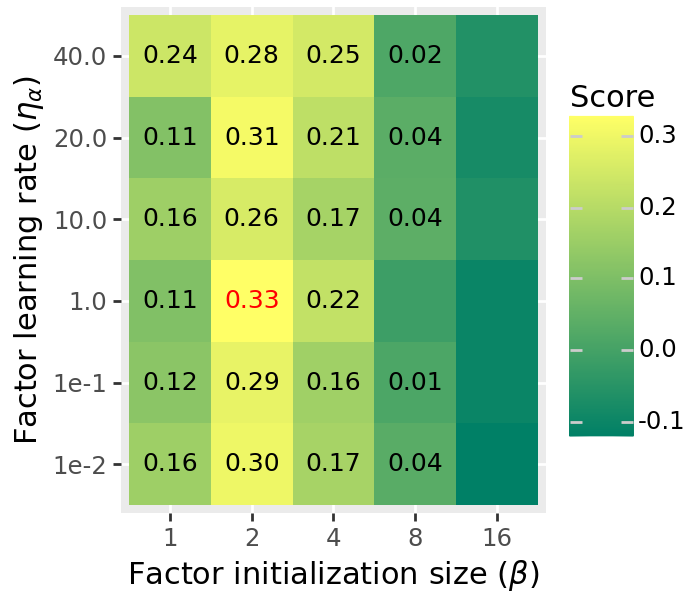

In [63]:
# difference of only one method w.r.t. vec init size

from plotnine import *


small_df = read_results(
    ["add_free"],
    [Path("/mnt/data/byt/reft_data", "concept_sweep_grid_default", cfg)],
    seed_list,
    factor_lr_list,
    factor_init_size_list,
)
large_df = read_results(
    ["add_free"],
    [Path("/mnt/data/byt/reft_data", "concept_sweep_grid_larger_vec", cfg)],
    seed_list,
    factor_lr_list,
    factor_init_size_list,
)

small_df = (
    small_df.groupby(["method", "factor_lr", "factor_init"])
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)
large_df = (
    large_df.groupby(["method", "factor_lr", "factor_init"])
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)
method = 'AddInv'
small_df = small_df[small_df['method']==method]
large_df = large_df[large_df['method']==method]


merged = large_df.copy()
del merged['overall_score'], merged['concept_score'], merged['instruct_score'], merged['fluency_score']

merged["Delta"] = large_df[f"{score_type}_score"] - small_df[f"{score_type}_score"]
# merged["Delta_text"] = merged["Delta"].apply(lambda x: f"{x:.2f}")
merged["Delta_text"] = merged["Delta"].apply(lambda x: f"{x:.2f}" if x > 0 else "")

text_colors = []
for _, row in merged.iterrows():
    if (
        abs(
            row["Delta"]
            - merged.groupby("method")["Delta"].max()[row["method"]]
        )
        < 1e-3
    ):
        text_colors.append("red")
    else:
        text_colors.append("black")
merged["text_color"] = text_colors

merged['factor_lr'] = merged['factor_lr'].apply(lambda s: float(s))
merged["factor_lr"] = pd.Categorical(
    merged["factor_lr"],
    categories=sorted(merged["factor_lr"].unique()),
    ordered=True,
)
merged["factor_init"] = pd.Categorical(
    merged["factor_init"],
    categories=sorted(merged["factor_init"].unique()),
    ordered=True,
)

plot = (
    ggplot(merged, aes(x="factor_init", y="factor_lr", fill="Delta"))
    + geom_tile()
    + geom_text(aes(label="Delta_text", color="text_color"), size=9)
    # + geom_text(aes(label="text"), size=8)
    + scale_color_manual({"black": "black", "red": "red"}, guide=None)
    + labs(
        x="Factor initialization size ($\\beta$)",
        y="Factor learning rate ($\\eta_\\alpha$)",
        fill="Score",
        # title=f"{score_type.capitalize()} score$\\uparrow$",
        # title="Concept score$\\uparrow$",
    )
    + theme(figure_size=(3.5, 3))
    + scale_y_discrete(
        labels=lambda lst: [
            f"{x:.1e}".replace("e-0", "e-").replace(".0", "") if x < 1 else f"{x}"
            for x in lst
        ],
    )
    + scale_fill_continuous('summer')
    # + scale_fill_gradient2(low='darkred', mid='white', high='steelblue')
    + coord_equal()
)

plot


In [12]:
# save_dir = Path("figures", f"{option}")
# save_dir.mkdir(parents=True, exist_ok=True)
# plot.save(save_dir / f"{cfg}_{positions}_diff.pdf", dpi=100)


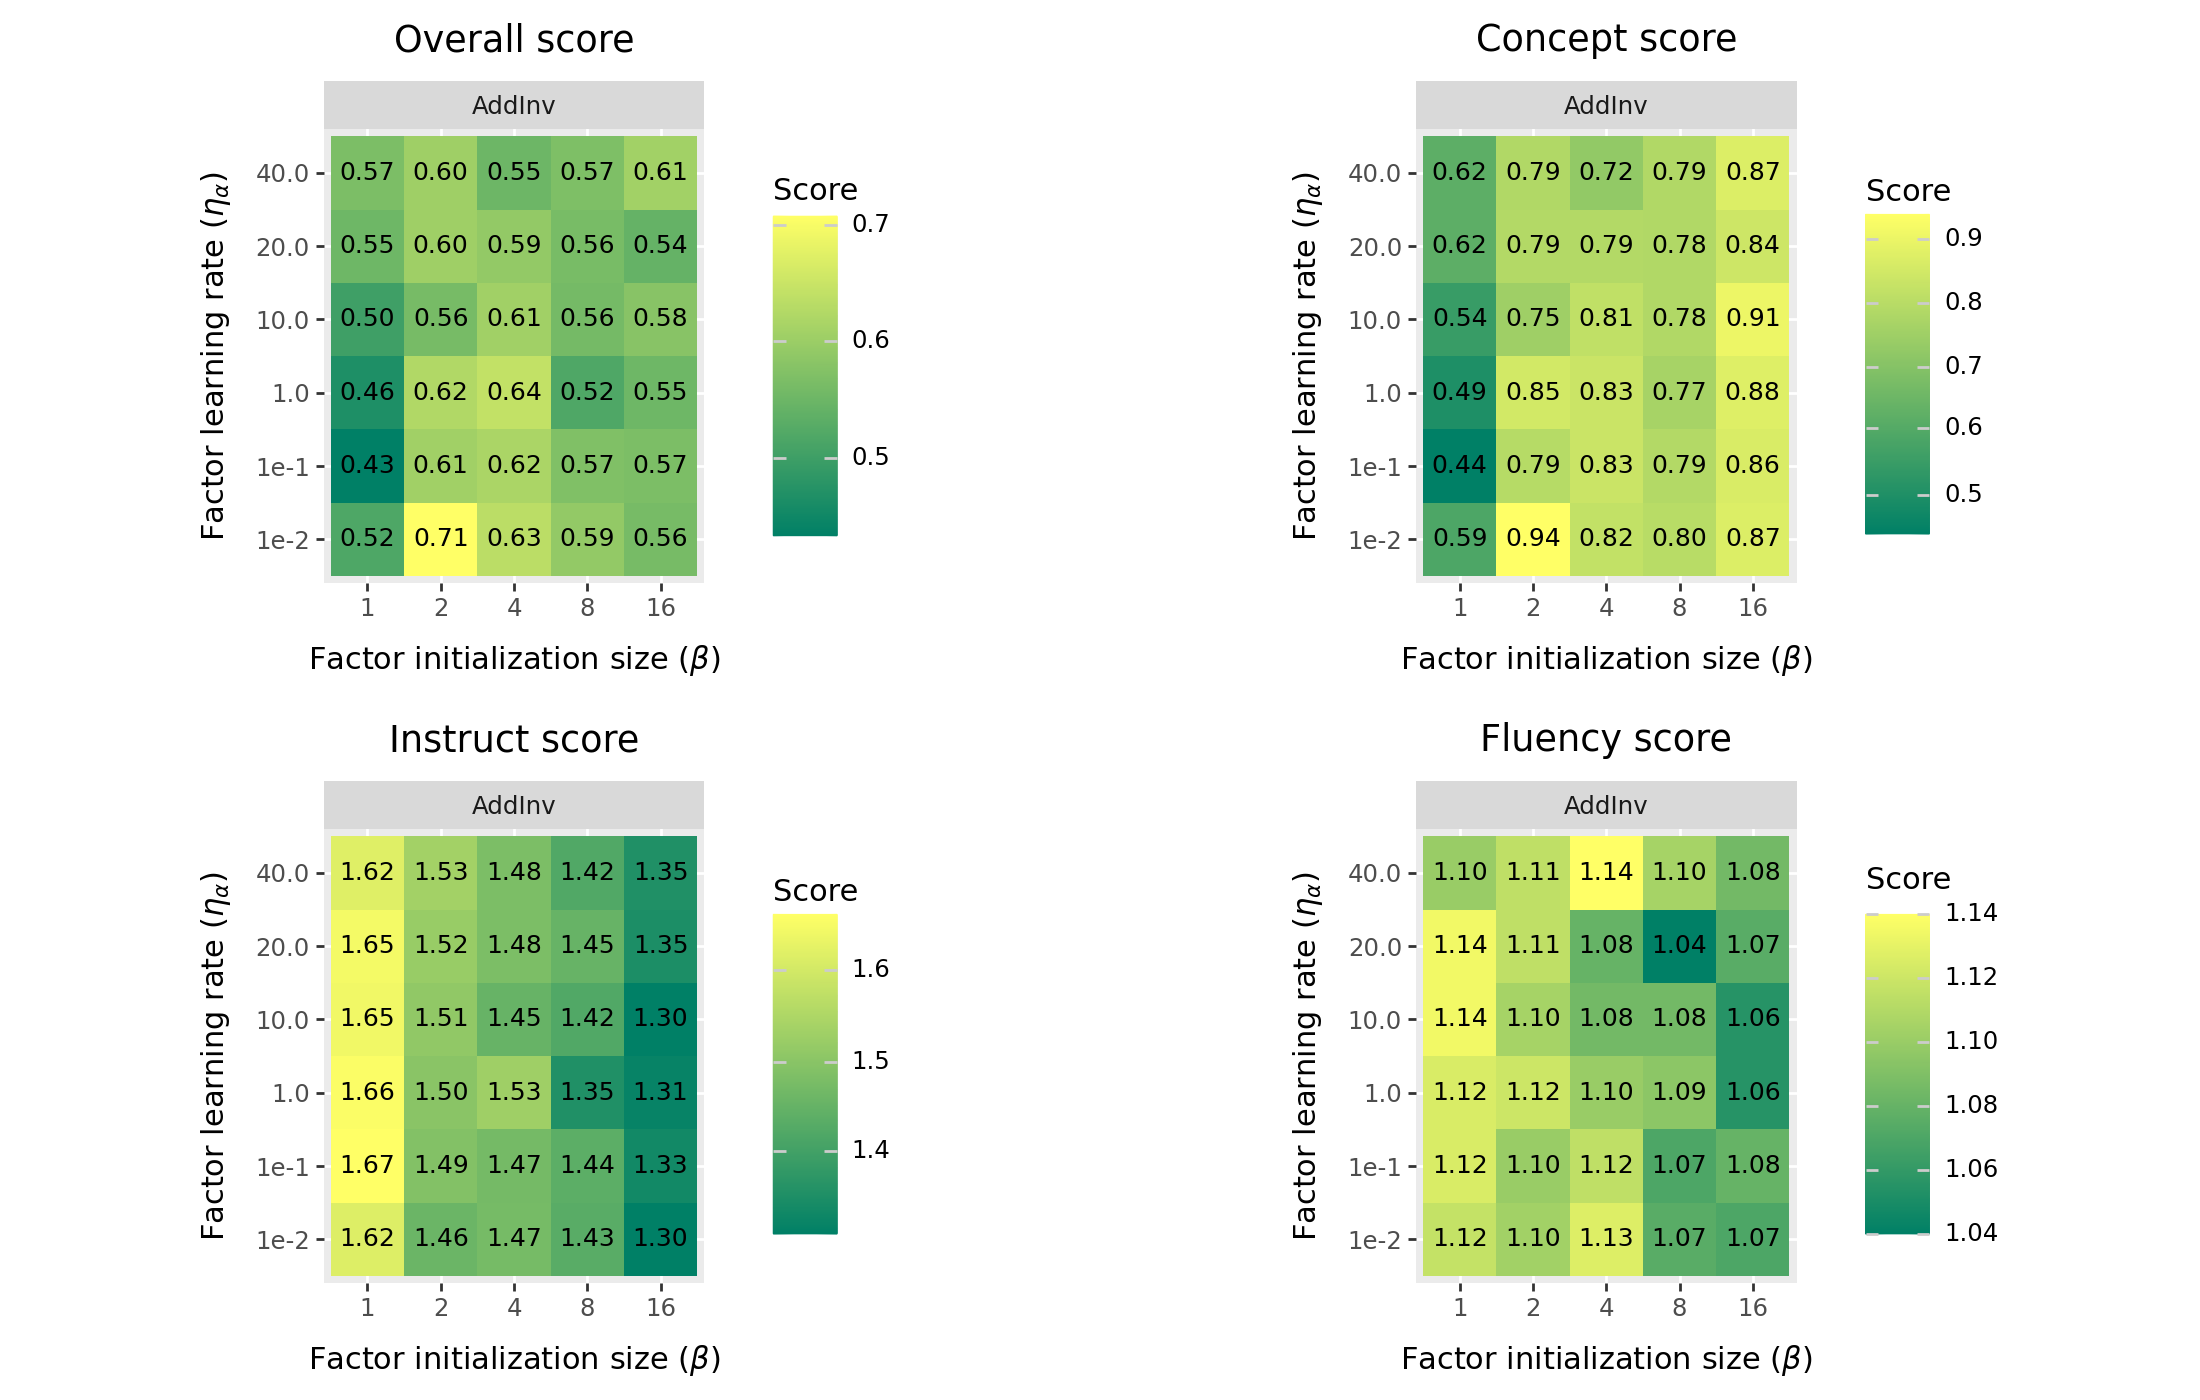

In [28]:
from plotnine import (
    ggplot,
    aes,
    geom_tile,
    geom_text,
    labs,
    theme,
    scale_y_discrete,
    scale_fill_gradient,
    coord_equal,
    facet_wrap,
)


# score_df = res_df[res_df["method"] == sv_key + "|" + positions]
score_df = (
    res_df.groupby(["method", "factor_lr", "factor_init", "seed"])
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)
score_df = (
    score_df.groupby(["method", "factor_lr", "factor_init"])
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)
plot_df = score_df.melt(
    id_vars=["method", "factor_lr", "factor_init"],
    value_vars=["overall_score", "concept_score", "instruct_score", "fluency_score"],
    var_name="score",
)
plot_df["score"] = plot_df["score"].replace(
    {
        "overall_score": "Overall score",
        "concept_score": "Concept score",
        "instruct_score": "Instruct score",
        "fluency_score": "Fluency score",
    }
)

plot_df["text"] = plot_df["value"].apply(lambda x: f"{x:.2f}")

plot_df["factor_lr"] = plot_df["factor_lr"].apply(lambda s: float(s))
plot_df["factor_lr"] = pd.Categorical(
    plot_df["factor_lr"],
    categories=sorted(plot_df["factor_lr"].unique()),
    ordered=True,
)
plot_df["factor_init"] = pd.Categorical(
    plot_df["factor_init"],
    categories=sorted(plot_df["factor_init"].unique()),
    ordered=True,
)

plots = []
for k in ("Overall", "Concept", "Instruct", "Fluency"):
    plot = (
        ggplot(
            plot_df[plot_df["score"] == f"{k} score"],
            aes(x="factor_init", y="factor_lr", fill="value"),
        )
        + geom_tile()
        + facet_wrap('method')
        + geom_text(aes(label="text"), size=9)
        + labs(
            x="Factor initialization size ($\\beta$)",
            y="Factor learning rate ($\\eta_\\alpha$)",
            fill="Score",
            title=f"{k} score",
        )
        + scale_y_discrete(
            labels=lambda lst: [
                f"{x:.1e}".replace("e-0", "e-").replace(".0", "") if x < 1 else f"{x}"
                for x in lst
            ],
        )
        # + scale_fill_gradient(low="white", high="steelblue")
        + scale_fill_continuous('summer')
        + coord_equal()
        + theme(figure_size=(11, 7))
    )
    plots.append(plot)

plot = (plots[0]/plots[2]) | (plots[1]/plots[3])
plot


In [296]:
# save_dir = Path("figures", f"{option}")
# save_dir.mkdir(parents=True, exist_ok=True)
# plot.save(save_dir / f"{cfg}_{positions}_all_scores.pdf", dpi=100)


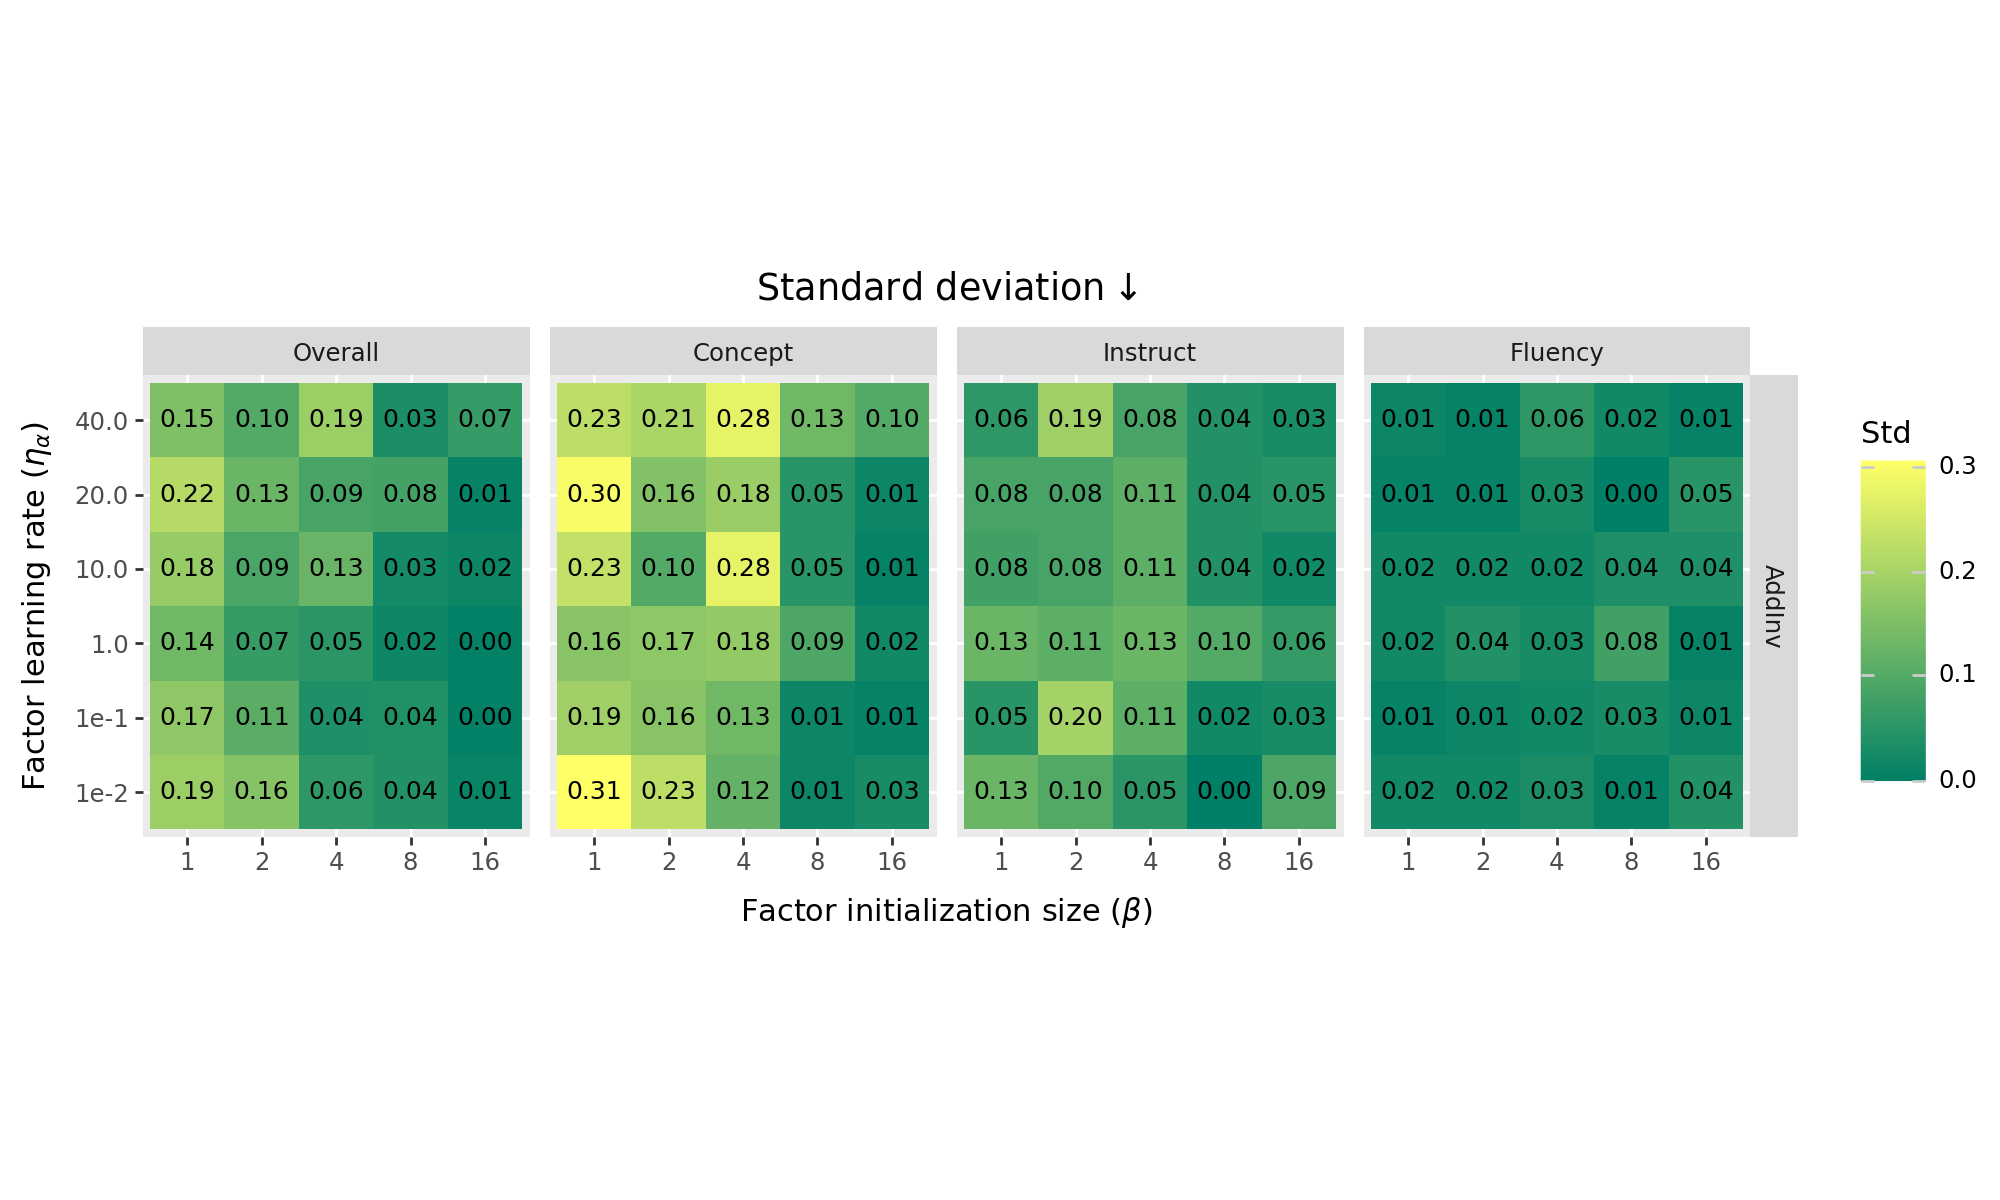

In [29]:
from plotnine import (
    ggplot,
    aes,
    geom_tile,
    geom_text,
    labs,
    theme,
    scale_y_discrete,
    facet_grid,
)


plot_df = (
    res_df.groupby(["method", "factor_lr", "factor_init", "seed"])
    .agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
    )
    .reset_index()
)
plot_df = (
    plot_df.groupby(["method", "factor_lr", "factor_init"])
    .agg(
        overall_std=("overall_score", "std"),
        concept_std=("concept_score", "std"),
        instruct_std=("instruct_score", "std"),
        fluency_std=("fluency_score", "std"),
    )
    .reset_index()
)
plot_df = plot_df.melt(
    id_vars=["method", "factor_lr", "factor_init"],
    value_vars=["overall_std", "concept_std", "instruct_std", "fluency_std"],
    var_name="score",
)
plot_df['score'] = plot_df['score'].replace(
    ["overall_std", "concept_std", "instruct_std", "fluency_std"],
    ["Overall", "Concept", "Instruct", "Fluency"],
)
plot_df["score"] = pd.Categorical(
    plot_df["score"],
    categories=["Overall", "Concept", "Instruct", "Fluency"],
    ordered=True,
)

plot_df['text'] = plot_df['value'].apply(lambda x: f"{x:.2f}")

plot_df['factor_lr'] = plot_df['factor_lr'].apply(lambda s: float(s))
plot_df["factor_lr"] = pd.Categorical(
    plot_df["factor_lr"],
    categories=sorted(plot_df["factor_lr"].unique()),
    ordered=True,
)
plot_df["factor_init"] = pd.Categorical(
    plot_df["factor_init"],
    categories=sorted(plot_df["factor_init"].unique()),
    ordered=True,
)

plot = (
    ggplot(plot_df, aes(x="factor_init", y="factor_lr", fill="value"))
    + geom_tile()
    + geom_text(aes(label="text"), size=9)
    + facet_grid('method ~ score')
    + labs(
        x="Factor initialization size ($\\beta$)",
        y="Factor learning rate ($\\eta_\\alpha$)",
        fill="Std",
        title="Standard deviation$\\downarrow$"
    )
    + theme(figure_size=(10, 6))
    + scale_y_discrete(
        labels=lambda lst: [
            f"{x:.1e}".replace("e-0", "e-").replace(".0", "") if x < 1 else f"{x}"
            for x in lst
        ],
    )
    # + scale_fill_gradient(low='steelblue', high='white')
    + scale_fill_continuous('summer')
    + coord_equal()
)
plot


In [ ]:
# save_dir = Path("figures", f"{option}")
# save_dir.mkdir(parents=True, exist_ok=True)
# plot.save(save_dir / f"{cfg}_{positions}_std.pdf", dpi=100)


# Aggregate plots

In [1]:
from collections import defaultdict
import pandas as pd

tradeoff_df = defaultdict(list)

# tradeoff_df['Method'].extend(['FSSV']*3)
# tradeoff_df['Overall score'].extend([0.65, 0.86, 0.93])
# tradeoff_df['Concept score'].extend([0.97, 1.17, 1.27])
# tradeoff_df['Instruct score'].extend([0.99, 1.31, 1.26])
# tradeoff_df['cfg'].extend(['G2B: L10', 'G9B: L20', 'Q32B: L32'])

# tradeoff_df['Method'].extend(['Full prompt']*3)
# tradeoff_df['Overall score'].extend([0.54, 0.71, 0.88])
# tradeoff_df['Concept score'].extend([0.84, 1.23, 1.29])
# tradeoff_df['Instruct score'].extend([1.24, 1.13, 1.27])
# tradeoff_df['cfg'].extend(['G2B: L10', 'G9B: L20', 'Q32B: L32'])

tradeoff_df['Method'].extend(['f1+l1']*3)
tradeoff_df['Overall score'].extend([0.67, 0.92, 1.10])
tradeoff_df['Concept score'].extend([0.73, 1.09, 1.24])
tradeoff_df['Instruct score'].extend([1.64, 1.41, 1.62])
tradeoff_df['cfg'].extend(['G2B: L10', 'G9B: L20', 'Q32B: L32'])

tradeoff_df['Method'].extend(['f2+l2']*3)
tradeoff_df['Overall score'].extend([0.70, 0.92, 1.16])
tradeoff_df['Concept score'].extend([0.82, 1.11, 1.33])
tradeoff_df['Instruct score'].extend([1.44, 1.51, 1.57])
tradeoff_df['cfg'].extend(['G2B: L10', 'G9B: L20', 'Q32B: L32'])

tradeoff_df['Method'].extend(['f4+l4']*3)
tradeoff_df['Overall score'].extend([0.69, 0.89, 1.13])
tradeoff_df['Concept score'].extend([0.78, 1.05, 1.30])
tradeoff_df['Instruct score'].extend([1.61, 1.51, 1.57])
tradeoff_df['cfg'].extend(['G2B: L10', 'G9B: L20', 'Q32B: L32'])

tradeoff_df = pd.DataFrame(tradeoff_df)


In [2]:
from collections import defaultdict
import pandas as pd
import numpy as np

def harmonic_mean(scores):
    # Return 0 if any score is 0 to maintain strict evaluation
    if 0 in scores:
        return 0.0
    return len(scores) / sum(1/s for s in scores)


def get_overall_score_concept_df(eval_df):
    harmonic_scores = []
    for _, row in eval_df.iterrows():
        mean = harmonic_mean(
            [row["concept_score"], row["relevance_score"], row["fluency_score"]]
        )
        harmonic_scores.append(mean)

    return np.mean(harmonic_scores).item()


In [ ]:
from collections import defaultdict
import itertools
from pathlib import Path
from tqdm import tqdm


def read_results(
    output_base_dir,
    svs,
    cfg_list,
    positions_list,
    seed_list,
    factor_lr_list,
    factor_init_size_list,
):
    res_df = defaultdict(list)

    for (
        cfg,
        positions,
        k,
        seed,
        factor_lr,
        factor_init,
    ) in tqdm(itertools.product(
        cfg_list,
        positions_list,
        svs,
        seed_list,
        factor_lr_list,
        factor_init_size_list,
    )):
        for concept_id in range(10):
            eval_path = (
                output_base_dir
                / cfg
                / f"outputs_{k}"
                / f"{positions}"
                / f"seed={seed}_scale={factor_init}_lr={factor_lr}"
                / f"{concept_id}"
                / "eval.parquet"
            )
            if not eval_path.exists():
                continue

            eval_df = pd.read_parquet(eval_path)
            # print(eval_df.iloc[0].to_dict())
            overall_score = get_overall_score_concept_df(eval_df)
            concept_score = eval_df["concept_score"].mean()
            instruct_score = eval_df["relevance_score"].mean()
            fluency_score = eval_df["fluency_score"].mean()

            res_df['cfg'].append(cfg)
            res_df["concept_id"].append(concept_id)
            res_df["method"].append(k)
            res_df["positions"].append(positions)
            res_df["seed"].append(seed)
            res_df["factor_lr"].append(factor_lr)
            res_df["factor_init"].append(factor_init)

            res_df["overall_score"].append(overall_score)
            res_df["concept_score"].append(concept_score)
            res_df["instruct_score"].append(instruct_score)
            res_df["fluency_score"].append(fluency_score)

    res_df = pd.DataFrame(res_df)
    if len(res_df) == 0:
        return None

    res_df["method"] = res_df["method"].replace(
        ["add_free", "clamp_free"], ["AddInv", "ClampInv"]
    )
    return res_df


In [4]:
output_base_dir = Path("/mnt/data/byt/reft_data", "concept_sweep_grid_larger_vec")
cfg_list = ["2b_l10", "9b_l20", "q25_32b_l32"]
seed_list = [42, 43, 44]
factor_lr_list = ['1e-2', '1e-1', '1', '10', '20', '40']
factor_init_size_list = [1, 2, 4, 8, 16]

positions_list = ["all", "all_prompt"] + ["f1+l1", "f2+l2", "f4+l4"] + ["f2", "f4", "f8"] + ["l2", "l4", "l8"]
# positions_list = ["f1+l1", "f2+l2", "f4+l4"]
# positions_list = ["f2", "f4", "f8"]
# positions_list = ["l2", "l4", "l8"]

res_df = read_results(
    output_base_dir=output_base_dir,
    cfg_list=cfg_list,
    svs=["add_free"],
    seed_list=seed_list,
    factor_lr_list=factor_lr_list,
    factor_init_size_list=factor_init_size_list,
    positions_list=positions_list,
)
res_df


,cfg,concept_id,method,positions,seed,factor_lr,factor_init,overall_score,concept_score,instruct_score,fluency_score
0,2b_l10,0,AddInv,all,42,1e-2,1,1.13,1.6,1.5,0.9
1,2b_l10,1,AddInv,all,42,1e-2,1,0.76,1.0,1.0,1.0
2,2b_l10,2,AddInv,all,42,1e-2,1,1.27,1.4,1.8,1.0
3,2b_l10,3,AddInv,all,42,1e-2,1,0.58,0.8,1.2,1.0
4,2b_l10,4,AddInv,all,42,1e-2,1,0.37,0.3,1.7,1.1
...,...,...,...,...,...,...,...,...,...,...,...
29085,q25_32b_l32,5,AddInv,l8,44,40,16,0.47,1.0,1.0,1.5
29086,q25_32b_l32,6,AddInv,l8,44,40,16,0.69,0.8,1.6,1.1
29087,q25_32b_l32,7,AddInv,l8,44,40,16,1.19,1.5,1.4,1.0
29088,q25_32b_l32,8,AddInv,l8,44,40,16,0.62,0.9,1.2,1.2


In [5]:
old_res_df = res_df.copy()

In [6]:
# res_df = res_df[res_df['seed']<43]
res_df = old_res_df[old_res_df['seed']>=44]
# res_df = old_res_df

In [7]:
# plot_df = res_df.groupby(['cfg', 'positions', 'factor_lr', 'factor_init', 'seed']).agg(
#         overall_score=("overall_score", "mean"),
#         concept_score=("concept_score", "mean"),
#         instruct_score=("instruct_score", "mean"),
#         fluency_score=("fluency_score", "mean"),
# ).reset_index()

# plot_df = plot_df.groupby(['cfg', 'positions', 'seed']).agg(
#         overall_score=("overall_score", "mean"),
#         concept_score=("concept_score", "mean"),
#         instruct_score=("instruct_score", "mean"),
#         fluency_score=("fluency_score", "mean"),
# ).reset_index()

# plot_df = plot_df.groupby(['cfg', 'positions', 'seed']).agg(
#         overall_score=("overall_score", "max"),
#         concept_score=("concept_score", "max"),
#         instruct_score=("instruct_score", "max"),
#         fluency_score=("fluency_score", "max"),
# ).reset_index()

# plot_df = plot_df.groupby(['cfg', 'positions']).agg(
#         overall_score=("overall_score", "mean"),
#         concept_score=("concept_score", "mean"),
#         instruct_score=("instruct_score", "mean"),
#         fluency_score=("fluency_score", "mean"),
# ).reset_index()

plot_df = res_df.groupby(['cfg', 'positions', 'factor_lr', 'factor_init']).agg(
        overall_score=("overall_score", "mean"),
        concept_score=("concept_score", "mean"),
        instruct_score=("instruct_score", "mean"),
        fluency_score=("fluency_score", "mean"),
).reset_index()

# plot_df = res_df.groupby(['cfg', 'positions']).agg(
        # overall_score=("overall_score", "mean"),
        # concept_score=("concept_score", "mean"),
        # instruct_score=("instruct_score", "mean"),
        # fluency_score=("fluency_score", "mean"),
# ).reset_index()

plot_df['line'] = [0]*len(plot_df)

plot_df


,cfg,positions,factor_lr,factor_init,overall_score,concept_score,instruct_score,fluency_score,line
0,2b_l10,all,1,1,0.695,0.82,1.46,1.02,0
1,2b_l10,all,1,2,0.669,0.93,1.01,1.02,0
2,2b_l10,all,1,4,0.000,0.78,0.00,0.01,0
3,2b_l10,all,1,8,0.000,0.38,0.00,0.00,0
4,2b_l10,all,1,16,0.000,0.34,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...
925,q25_32b_l32,l8,40,1,0.897,1.09,1.43,1.34,0
926,q25_32b_l32,l8,40,2,0.836,0.97,1.58,1.34,0
927,q25_32b_l32,l8,40,4,0.849,1.02,1.46,1.36,0
928,q25_32b_l32,l8,40,8,0.822,1.05,1.39,1.31,0


In [30]:
def get_harmonic(os):
    x = []
    y = []
    for xi in np.linspace(0, 2, 200):
        for yi in np.linspace(0, 2, 200):
            if abs(harmonic_mean([xi, yi, os]) - os) < 1e-3:
                x.append(xi.item())
                y.append(yi.item())
    return x, y

tmp_dfs = []

s = 1.08
x, y = get_harmonic(s)
tmp_df = defaultdict(list)
tmp_df['concept_score'].extend(x)
tmp_df['instruct_score'].extend(y)
tmp_df['fluency_score'].extend([s]*len(x))
tmp_df['overall_score'].extend([s]*len(x))
tmp_df['cfg'].extend(['2b_l10']*len(x))
tmp_df['positions'].extend(['none']*len(x))
tmp_df['factor_lr'].extend(['0']*len(x))
tmp_df['factor_init'].extend([0]*len(x))
tmp_df['line'].extend([""]*(len(x)-1) + [f"{s:.2f}"])
tmp_df = pd.DataFrame(tmp_df)
tmp_dfs.append(tmp_df)

s = 0.65
x, y = get_harmonic(s)
tmp_df = defaultdict(list)
tmp_df['concept_score'].extend(x)
tmp_df['instruct_score'].extend(y)
tmp_df['fluency_score'].extend([s]*len(x))
tmp_df['overall_score'].extend([s]*len(x))
tmp_df['cfg'].extend(['2b_l10']*len(x))
tmp_df['positions'].extend(['none']*len(x))
tmp_df['factor_lr'].extend(['0']*len(x))
tmp_df['factor_init'].extend([0]*len(x))
tmp_df['line'].extend([""]*(len(x)-1) + [f"{s:.2f}"])
tmp_df = pd.DataFrame(tmp_df)
tmp_dfs.append(tmp_df)

s = 1.30
x, y = get_harmonic(s)
tmp_df = defaultdict(list)
tmp_df['concept_score'].extend(x)
tmp_df['instruct_score'].extend(y)
tmp_df['fluency_score'].extend([s]*len(x))
tmp_df['overall_score'].extend([s]*len(x))
tmp_df['cfg'].extend(['9b_l20']*len(x))
tmp_df['positions'].extend(['none']*len(x))
tmp_df['factor_lr'].extend(['0']*len(x))
tmp_df['factor_init'].extend([0]*len(x))
tmp_df['line'].extend([""]*(len(x)-1) + [f"{s:.2f}"])
tmp_df = pd.DataFrame(tmp_df)
tmp_dfs.append(tmp_df)

s = 0.8
x, y = get_harmonic(s)
tmp_df = defaultdict(list)
tmp_df['concept_score'].extend(x)
tmp_df['instruct_score'].extend(y)
tmp_df['fluency_score'].extend([s]*len(x))
tmp_df['overall_score'].extend([s]*len(x))
tmp_df['cfg'].extend(['9b_l20']*len(x))
tmp_df['positions'].extend(['none']*len(x))
tmp_df['factor_lr'].extend(['0']*len(x))
tmp_df['factor_init'].extend([0]*len(x))
tmp_df['line'].extend([""]*(len(x)-1) + [f"{s:.2f}"])
tmp_df = pd.DataFrame(tmp_df)
tmp_dfs.append(tmp_df)

s = 1.42
x, y = get_harmonic(s)
tmp_df = defaultdict(list)
tmp_df['concept_score'].extend(x)
tmp_df['instruct_score'].extend(y)
tmp_df['fluency_score'].extend([s]*len(x))
tmp_df['overall_score'].extend([s]*len(x))
tmp_df['cfg'].extend(['q25_32b_l32']*len(x))
tmp_df['positions'].extend(['none']*len(x))
tmp_df['factor_lr'].extend(['0']*len(x))
tmp_df['factor_init'].extend([0]*len(x))
tmp_df['line'].extend([""]*(len(x)-1) + [f"{s:.2f}"])
tmp_df = pd.DataFrame(tmp_df)
tmp_dfs.append(tmp_df)

s = 0.9
x, y = get_harmonic(s)
tmp_df = defaultdict(list)
tmp_df['concept_score'].extend(x)
tmp_df['instruct_score'].extend(y)
tmp_df['fluency_score'].extend([s]*len(x))
tmp_df['overall_score'].extend([s]*len(x))
tmp_df['cfg'].extend(['q25_32b_l32']*len(x))
tmp_df['positions'].extend(['none']*len(x))
tmp_df['factor_lr'].extend(['0']*len(x))
tmp_df['factor_init'].extend([0]*len(x))
tmp_df['line'].extend([f"{s:.2f}"] + [""]*(len(x)-1))
tmp_df = pd.DataFrame(tmp_df)
tmp_dfs.append(tmp_df)

s = 0.75
x, y = get_harmonic(s)
tmp_df = defaultdict(list)
tmp_df['concept_score'].extend(x)
tmp_df['instruct_score'].extend(y)
tmp_df['fluency_score'].extend([s]*len(x))
tmp_df['overall_score'].extend([s]*len(x))
tmp_df['cfg'].extend(['q25_32b_l32']*len(x))
tmp_df['positions'].extend(['none']*len(x))
tmp_df['factor_lr'].extend(['0']*len(x))
tmp_df['factor_init'].extend([0]*len(x))
tmp_df['line'].extend([f"{s:.2f}"] + [""]*(len(x)-1))
tmp_df = pd.DataFrame(tmp_df)
tmp_dfs.append(tmp_df)

tmp_df = pd.concat(tmp_dfs, ignore_index=True)

/tmp/ipykernel_2451139/1428896814.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_2451139/1428896814.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


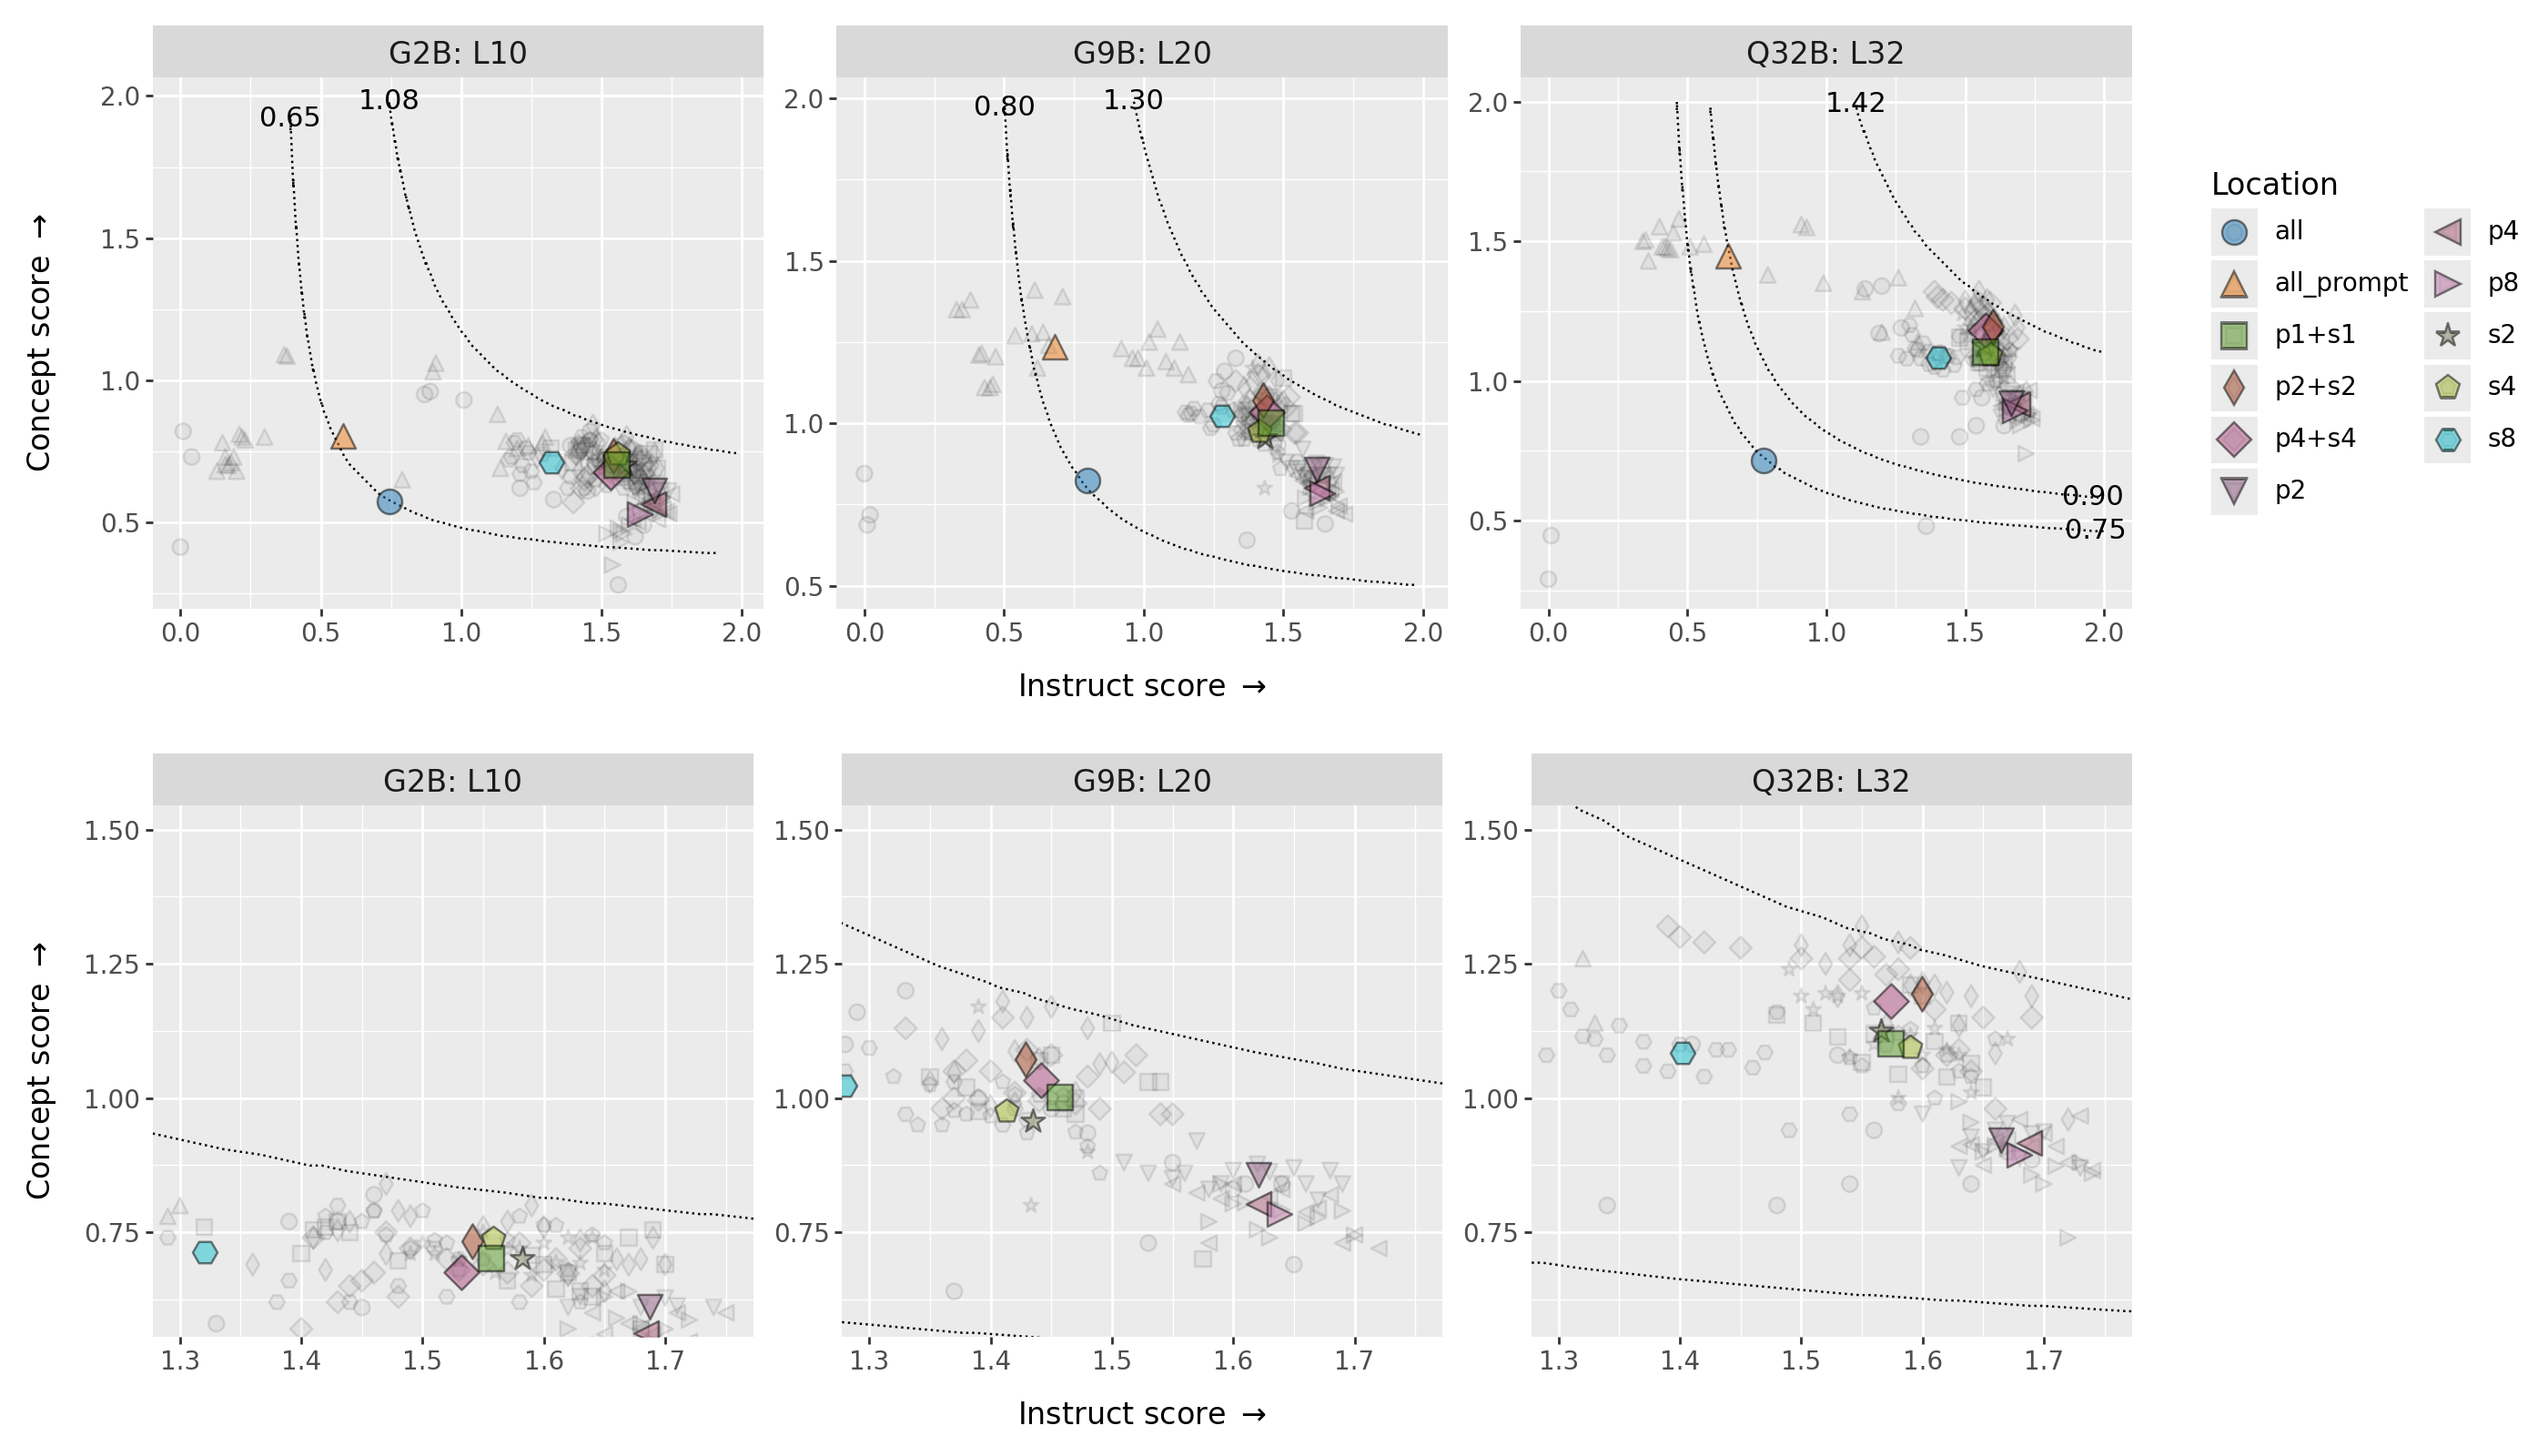

In [31]:
from plotnine import *

plot_df["positions"] = plot_df["positions"].replace(
    ["f1+l1", "f2+l2", "f4+l4", "f2", "f4", "f8", "l2", "l4", "l8"],
    [
        x.replace("f", "p").replace("l", "s")
        for x in ["f1+l1", "f2+l2", "f4+l4", "f2", "f4", "f8", "l2", "l4", "l8"]
    ],
)
plot_df["positions"] = pd.Categorical(
    plot_df["positions"],
    categories=[
        "all",
        "all_prompt",
        "p1+s1",
        "p2+s2",
        "p4+s4",
        "p2",
        "p4",
        "p8",
        "s2",
        "s4",
        "s8",
    ],
    ordered=True,
)
plot_df['cfg'] = plot_df['cfg'].replace(['2b_l10', '9b_l20', 'q25_32b_l32'], ['G2B: L10', 'G9B: L20', 'Q32B: L32'])
tmp_df['cfg'] = tmp_df['cfg'].replace(['2b_l10', '9b_l20', 'q25_32b_l32'], ['G2B: L10', 'G9B: L20', 'Q32B: L32'])

plot = (
    ggplot(
        plot_df,
        aes(
            x="instruct_score",
            y="concept_score",
        ),
    )
    + facet_wrap("cfg", scales="free")
    + geom_line(tmp_df, aes(group='overall_score'), linetype="dotted")
    + stat_summary(
        plot_df,
        aes(shape="positions"),
        fill="gray",
        geom="point",
        size=3,
        alpha=0.1,
    )
    + geom_point(
        plot_df
        .groupby(["cfg", "positions"])
        .agg(
            concept_score=("concept_score", "mean"),
            instruct_score=("instruct_score", "mean"),
            overall_score=("overall_score", "mean"),
        )
        .reset_index(),
        aes(shape="positions", fill="positions"),
        size=5,
        alpha=0.5,
    )
    + labs(
        x="Instruct score $\\rightarrow$",
        y="Concept score $\\rightarrow$",
        fill="Location",
        shape="Location",
    )
    + scale_fill_cmap_d('tab10')
    + scale_shape_manual(["o", "^", "s", "d", "D", "v", "<", ">", "*", "p", "H"])
    + theme(
        figure_size=(14, 8),
        legend_position="right",
        strip_text=element_text(size=12),
        legend_title=element_text(size=12),
        legend_text=element_text(size=10),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
    )
    + guides(fill=guide_legend(ncol=2), shape=guide_legend(ncol=2))
    + geom_text(tmp_df, aes(label='line'))
)

plot_zoom = (
    ggplot(
        plot_df,
        aes(
            x="instruct_score",
            y="concept_score",
        ),
    )
    + facet_wrap("cfg", scales="free")
    + geom_line(tmp_df, aes(group='overall_score'), linetype="dotted")
    + stat_summary(
        plot_df,
        aes(shape="positions"),
        fill="gray",
        geom="point",
        size=3,
        alpha=0.1,
    )
    + geom_point(
        plot_df
        .groupby(["cfg", "positions"])
        .agg(
            concept_score=("concept_score", "mean"),
            instruct_score=("instruct_score", "mean"),
            overall_score=("overall_score", "mean"),
        )
        .reset_index(),
        aes(shape="positions", fill="positions"),
        size=5,
        alpha=0.5,
    )
    + labs(
        x="Instruct score $\\rightarrow$",
        y="Concept score $\\rightarrow$",
        fill="Location",
        shape="Location",
    )
    + scale_fill_cmap_d('tab10')
    + scale_shape_manual(["o", "^", "s", "d", "D", "v", "<", ">", "*", "p", "H"])
    + theme(
        figure_size=(14, 8),
        strip_text=element_text(size=12),
        axis_title=element_text(size=12),
        axis_text=element_text(size=10),
    )
    + guides(fill='none', shape='none')
    + coord_cartesian([1.3, 1.75], [0.6, 1.5])
)


composite_plot = plot / plot_zoom
composite_plot


In [ ]:
# composite_plot.save('figures/locations_aggregated.pdf')

In [10]:
# from plotnine import *

# plot_df["positions"] = plot_df["positions"].replace(
#     ["f1+l1", "f2+l2", "f4+l4", "f2", "f4", "f8", "l2", "l4", "l8"],
#     [
#         x.replace("f", "p").replace("l", "s")
#         for x in ["f1+l1", "f2+l2", "f4+l4", "f2", "f4", "f8", "l2", "l4", "l8"]
#     ],
# )
# plot_df["positions"] = pd.Categorical(
#     plot_df["positions"],
#     categories=[
#         "all",
#         "all_prompt",
#         "p1+s1",
#         "p2+s2",
#         "p4+s4",
#         "p2",
#         "p4",
#         "p8",
#         "s2",
#         "s4",
#         "s8",
#     ],
#     ordered=True,
# )

# plot = (
#     ggplot(
#         plot_df,
#         aes(
#             x="concept_score",
#             y="overall_score",
#         ),
#     )
#     + facet_wrap("cfg", scales="free")
#     + stat_summary(
#         plot_df,
#         aes(shape="positions"),
#         fill="gray",
#         geom="point",
#         size=3,
#         alpha=0.1,
#     )
#     + geom_point(
#         plot_df
#         .groupby(["cfg", "positions"])
#         .agg(
#             concept_score=("concept_score", "mean"),
#             instruct_score=("instruct_score", "mean"),
#             overall_score=("overall_score", "mean"),
#         )
#         .reset_index(),
#         aes(shape="positions", fill="positions"),
#         size=8,
#         alpha=0.5,
#     )
#     + labs(
#         x="Concept score $\\rightarrow$",
#         y="Overall score $\\rightarrow$",
#         fill="Location",
#         shape="Location",
#     )
#     + scale_fill_cmap_d('tab10')
#     + scale_shape_manual(["o", "^", "s", "d", "D", "v", "<", ">", "*", "p", "H"])
#     + theme(
#         figure_size=(14, 4),
#         legend_position="right",
#     )
#     + guides(fill=guide_legend(ncol=2), shape=guide_legend(ncol=2))
# )
# plot


In [151]:
plot_df

,cfg,positions,overall_score,concept_score,instruct_score,fluency_score,line
0,2b_l10,p1+s1,0.695333,0.816667,1.690000,1.100000,False
1,2b_l10,p2+s2,0.721667,0.883333,1.663333,1.093333,False
2,2b_l10,p4+s4,0.708667,0.820000,1.646667,1.120000,False
3,9b_l20,p1+s1,0.929000,1.150000,1.525000,1.166667,False
4,9b_l20,p2+s2,0.942000,1.150000,1.593333,1.196667,False
5,9b_l20,p4+s4,0.947667,1.163333,1.580000,1.180000,False
6,q25_32b_l32,p1+s1,1.126333,1.270000,1.670000,1.423333,False
7,q25_32b_l32,p2+s2,1.200333,1.363333,1.693333,1.423333,False
8,q25_32b_l32,p4+s4,1.194000,1.360000,1.690000,1.446667,False


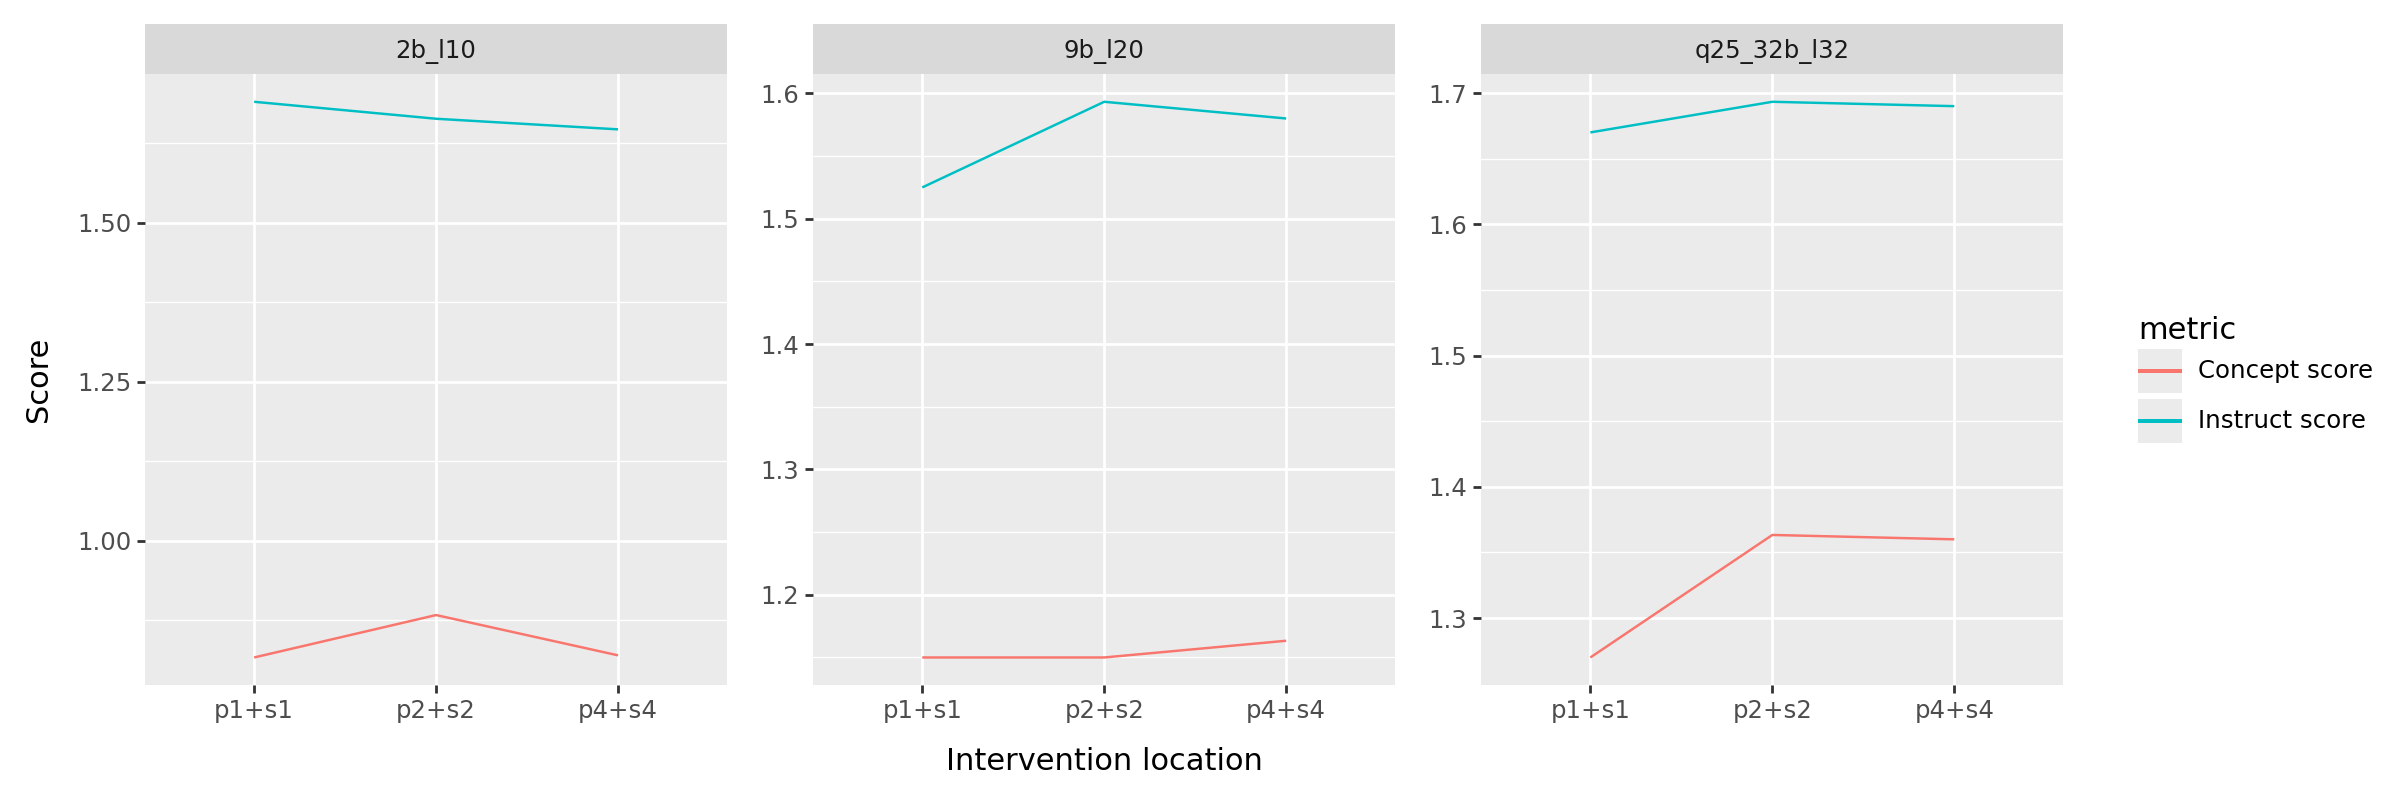

In [154]:
from plotnine import *

line_df = plot_df.melt(id_vars=['cfg', 'positions'], value_vars=['concept_score', 'instruct_score'], var_name='metric')

# line_df = plot_df.groupby(['cfg', 'positions']).agg(
#     concept_score=('concept_score', 'max'),
#     instruct_score=('instruct_score', 'max'),
# ).reset_index().melt(id_vars=['cfg', 'positions'], value_vars=['concept_score', 'instruct_score'], var_name='metric')

line_df['metric'] = line_df['metric'].replace(['concept_score', 'instruct_score'], ['Concept score', 'Instruct score'])

plot = (
    ggplot(line_df, aes(x="positions", y="value"))
    + facet_wrap('cfg', scales='free_y')
    + stat_summary(aes(color='metric', group='metric'), geom="line", fun_data='mean_cl_boot')
    # + geom_boxplot(aes(color='metric'))
    + labs(x="Intervention location", y="Score")
    + theme(figure_size=(12,4))
)
plot
